# German Credit — Clean EDA, Leakage-Safe Feature Selection and Cost Optimization

This notebook is a clean, end-to-end experiment for the supplied German Credit
project. It keeps the useful visual exploration style of an introductory
tutorial, while enforcing a stricter model-selection protocol:

1. EDA uses the 640-row development sample only.
2. Missing-value handling, scaling, encoding and calibration are fitted inside
   training folds through scikit-learn pipelines.
3. Four feature sets are declared before results are inspected.
4. Feature set, model configuration and decision threshold are selected inside
   three-fold inner CV.
5. Five outer folds estimate the complete selection procedure.
6. The 160-row historical benchmark is evaluated only after the rule is frozen.
7. The 200 competition rows are never used for tuning.

The primary objective is

\[
\operatorname{Cost}=\frac{5FN_{Bad}+FP_{Bad}}{N}.
\]

Recall-Bad, Precision-Bad, F1-Bad, Average Precision, ROC-AUC, KS, Brier
score, calibration and fold stability are supporting diagnostics. Accuracy is
reported but is not the selection target.

Run all cells from top to bottom. A CPU runtime is sufficient. The complete
run can take several minutes because the feature set is selected inside nested
cross-validation.

In [ ]:
from pathlib import Path
from datetime import datetime, timezone
from time import perf_counter
import hashlib
import json
import os
import platform
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from IPython.display import display

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 80)
pd.set_option("display.precision", 4)
sns.set_theme(style="whitegrid", context="notebook")

SEED = 42
PRIMARY_FN_COST = 5.0
PRIMARY_FP_COST = 1.0

# This environment switch is only for a quick local code check. Colab uses the
# complete settings because the variable is absent there.
SMOKE_TEST = os.getenv("CREDIT_NOTEBOOK_SMOKE", "0") == "1"
OUTER_FOLDS = 2 if SMOKE_TEST else 5
INNER_FOLDS = 2 if SMOKE_TEST else 3
PERMUTATION_REPEATS = 2 if SMOKE_TEST else 20
ROBUST_THRESHOLD_TOLERANCE = 0.01
THRESHOLD_GRID = np.r_[0.00, np.arange(0.01, 1.00, 0.01), 1.01]

print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("Smoke-test mode:", SMOKE_TEST)

Python: 3.13.15
pandas: 2.2.3
scikit-learn: 1.6.1
Smoke-test mode: False


## 1. Locate the supplied files

Preferred Colab layout:

```text
MyDrive/German_Credit_Colab/
└── Final_Project/
    ├── data/train.csv
    ├── data/test.csv
    └── data_splits_colab/        # optional fixed split IDs
```

If the folder has a different name, change only `MANUAL_PROJECT_DIR`.

In [ ]:
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")

MANUAL_PROJECT_DIR = None

candidates = []
if MANUAL_PROJECT_DIR:
    candidates.append(Path(MANUAL_PROJECT_DIR))
if IN_COLAB:
    candidates.extend([
        Path("/content/drive/MyDrive/German_Credit_Colab/Final_Project"),
        Path("/content/drive/MyDrive/German_Credit_Colab"),
    ])
else:
    cwd = Path.cwd()
    candidates.extend([
        cwd,
        cwd / "project_ml/german_credit_final",
        cwd.parent / "german_credit_final",
    ])

PROJECT = next((p for p in candidates if (p / "data/train.csv").is_file()), None)
if PROJECT is None:
    raise FileNotFoundError(
        "Could not find data/train.csv. Set MANUAL_PROJECT_DIR to the folder "
        "containing the data subfolder."
    )

DATA_DIR = PROJECT / "data"
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ")
default_output_root = PROJECT / "feature_selection_outputs"
OUTPUT_ROOT = Path(os.environ.get("GERMAN_CREDIT_OUTPUT_ROOT", default_output_root))
OUTPUT_DIR = OUTPUT_ROOT / RUN_ID
FIGURE_DIR = OUTPUT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=False)
started = perf_counter()

print("Project folder:", PROJECT)
print("Output folder:", OUTPUT_DIR)

Mounted at /content/drive
Project folder: /content/drive/MyDrive/German_Credit_Colab/Final_Project
Output folder: /content/drive/MyDrive/German_Credit_Colab/Final_Project/feature_selection_outputs/20260923T180837_080058Z


## 2. Load, rename and audit the data

The source target is `kredit=1` for Good and `kredit=0` for Bad. The notebook
models `bad_credit = 1 - kredit`, so Bad is consistently the positive class.
`Id` and both target columns are never model inputs.

In [ ]:
RENAME = {
    "laufkont": "status",
    "laufzeit": "duration",
    "moral": "credit_history",
    "verw": "purpose",
    "hoehe": "amount",
    "sparkont": "savings",
    "beszeit": "employment_duration",
    "rate": "installment_rate",
    "famges": "personal_status_sex",
    "buerge": "other_debtors",
    "wohnzeit": "present_residence",
    "verm": "property",
    "alter": "age",
    "weitkred": "other_installment_plans",
    "wohn": "housing",
    "bishkred": "number_credits",
    "beruf": "job",
    "pers": "people_liable",
    "telef": "telephone",
    "gastarb": "foreign_worker",
    "kredit": "credit_risk",
}

train_raw = pd.read_csv(DATA_DIR / "train.csv")
competition_raw = pd.read_csv(DATA_DIR / "test.csv")
train = train_raw.rename(columns=RENAME).set_index("Id")
competition = competition_raw.rename(columns=RENAME).set_index("Id")

assert "credit_risk" in train.columns
assert "credit_risk" not in competition.columns
assert set(train["credit_risk"].unique()) == {0, 1}

X = train.drop(columns="credit_risk")
y = (1 - train["credit_risk"]).astype(int).rename("bad_credit")

assert X.shape[1] == 20
assert X.columns.tolist() == competition.columns.tolist()
assert X.index.is_unique and competition.index.is_unique
assert set(X.index).isdisjoint(competition.index)

input_files = [DATA_DIR / "train.csv", DATA_DIR / "test.csv"]
input_hashes = {p.name: hashlib.sha256(p.read_bytes()).hexdigest() for p in input_files}

quality = pd.DataFrame({
    "Check": [
        "Labeled rows", "Competition rows", "Raw predictors", "Good rows", "Bad rows",
        "Missing labeled cells", "Missing competition cells", "Repeated labeled profiles",
    ],
    "Value": [
        len(X), len(competition), X.shape[1], int((y == 0).sum()), int((y == 1).sum()),
        int(X.isna().sum().sum()), int(competition.isna().sum().sum()), int(X.duplicated().sum()),
    ],
})
display(quality)
quality.to_csv(OUTPUT_DIR / "data_quality.csv", index=False)

,Check,Value
0,Labeled rows,800
1,Competition rows,200
2,Raw predictors,20
3,Good rows,600
4,Bad rows,200
5,Missing labeled cells,0
6,Missing competition cells,0
7,Repeated labeled profiles,0


## 3. Preserve the fixed 640/160 split

Split IDs are a project contract. The 160-row historical benchmark has been
inspected before, so it is a diagnostic benchmark rather than a fresh blind
test. The primary evidence is the outer CV performance on the 640 development
rows.

In [ ]:
split_pairs = [
    (PROJECT / "data_splits_colab/development_ids.csv", PROJECT / "data_splits_colab/historical_benchmark_ids.csv"),
    (PROJECT / "splits/development_ids.csv", PROJECT / "splits/holdout_ids.csv"),
    (PROJECT / "outputs/development_ids.csv", PROJECT / "outputs/holdout_ids.csv"),
]
split_pair = next(((a, b) for a, b in split_pairs if a.is_file() and b.is_file()), None)

if split_pair:
    development_ids = pd.read_csv(split_pair[0])["Id"].astype(int).tolist()
    benchmark_ids = pd.read_csv(split_pair[1])["Id"].astype(int).tolist()
    split_source = f"Saved IDs: {split_pair[0].name}, {split_pair[1].name}"
else:
    development_ids, benchmark_ids = train_test_split(
        X.index.to_numpy(),
        test_size=0.20,
        random_state=SEED,
        stratify=y.to_numpy(),
    )
    development_ids = list(map(int, development_ids))
    benchmark_ids = list(map(int, benchmark_ids))
    split_source = "Reproduced stratified 80/20 split with seed 42"

assert len(development_ids) == 640 and len(benchmark_ids) == 160
assert set(development_ids).isdisjoint(benchmark_ids)
assert set(development_ids) | set(benchmark_ids) == set(X.index)

X_dev, y_dev = X.loc[development_ids].copy(), y.loc[development_ids].copy()
X_benchmark, y_benchmark = X.loc[benchmark_ids].copy(), y.loc[benchmark_ids].copy()

pd.DataFrame({"Id": development_ids}).to_csv(OUTPUT_DIR / "development_ids.csv", index=False)
pd.DataFrame({"Id": benchmark_ids}).to_csv(OUTPUT_DIR / "historical_benchmark_ids.csv", index=False)

split_summary = pd.DataFrame([
    {"Split": "Development", "Rows": len(y_dev), "Good": int((y_dev == 0).sum()), "Bad": int(y_dev.sum())},
    {"Split": "Historical benchmark", "Rows": len(y_benchmark), "Good": int((y_benchmark == 0).sum()), "Bad": int(y_benchmark.sum())},
    {"Split": "Competition", "Rows": len(competition), "Good": np.nan, "Bad": np.nan},
])
print(split_source)
display(split_summary)
split_summary.to_csv(OUTPUT_DIR / "split_summary.csv", index=False)

Saved IDs: development_ids.csv, historical_benchmark_ids.csv


,Split,Rows,Good,Bad
0,Development,640,480.0,160.0
1,Historical benchmark,160,120.0,40.0
2,Competition,200,NaN,NaN


## 4. Development-only EDA

These plots borrow the clarity of the referenced YouTube tutorial—class
balance, numerical distributions and categorical Bad rates—but they use only
the development sample. The benchmark and competition data remain unseen.
EDA is descriptive and does not directly select the final model.

,Class,Count,Rate
0,Good,480,0.75
1,Bad,160,0.25


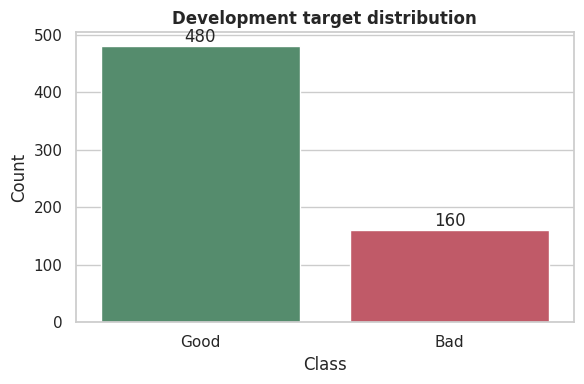

In [ ]:
eda = X_dev.copy()
eda["bad_credit"] = y_dev
eda["credit_label"] = np.where(eda["bad_credit"].eq(1), "Bad", "Good")

class_table = (
    eda["credit_label"].value_counts()
    .rename_axis("Class")
    .reset_index(name="Count")
)
class_table["Rate"] = class_table["Count"] / len(eda)
display(class_table)
class_table.to_csv(OUTPUT_DIR / "eda_class_distribution.csv", index=False)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=class_table, x="Class", y="Count", hue="Class", palette={"Good": "#4C956C", "Bad": "#D1495B"}, legend=False, ax=ax)
ax.set_title("Development target distribution", weight="bold")
for container in ax.containers:
    ax.bar_label(container)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "eda_class_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

In [ ]:
missing_table = pd.DataFrame({
    "Feature": X_dev.columns,
    "Missing count": X_dev.isna().sum().to_numpy(),
    "Missing rate": X_dev.isna().mean().to_numpy(),
}).sort_values(["Missing rate", "Feature"], ascending=[False, True])
display(missing_table)
missing_table.to_csv(OUTPUT_DIR / "eda_missing_values.csv", index=False)

if missing_table["Missing count"].sum() == 0:
    print("No missing development cells. Imputers remain in the pipelines for deployment safety.")
else:
    fig, ax = plt.subplots(figsize=(9, 4))
    plot_missing = missing_table.query("`Missing count` > 0")
    sns.barplot(data=plot_missing, x="Missing rate", y="Feature", color="#7AA6C2", ax=ax)
    ax.set_title("Development missing-value rates", weight="bold")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "eda_missing_values.png", dpi=180, bbox_inches="tight")
    plt.show()

,Feature,Missing count,Missing rate
12,age,0,0.0
4,amount,0,0.0
2,credit_history,0,0.0
1,duration,0,0.0
6,employment_duration,0,0.0
19,foreign_worker,0,0.0
14,housing,0,0.0
7,installment_rate,0,0.0
16,job,0,0.0
15,number_credits,0,0.0


No missing development cells. Imputers remain in the pipelines for deployment safety.


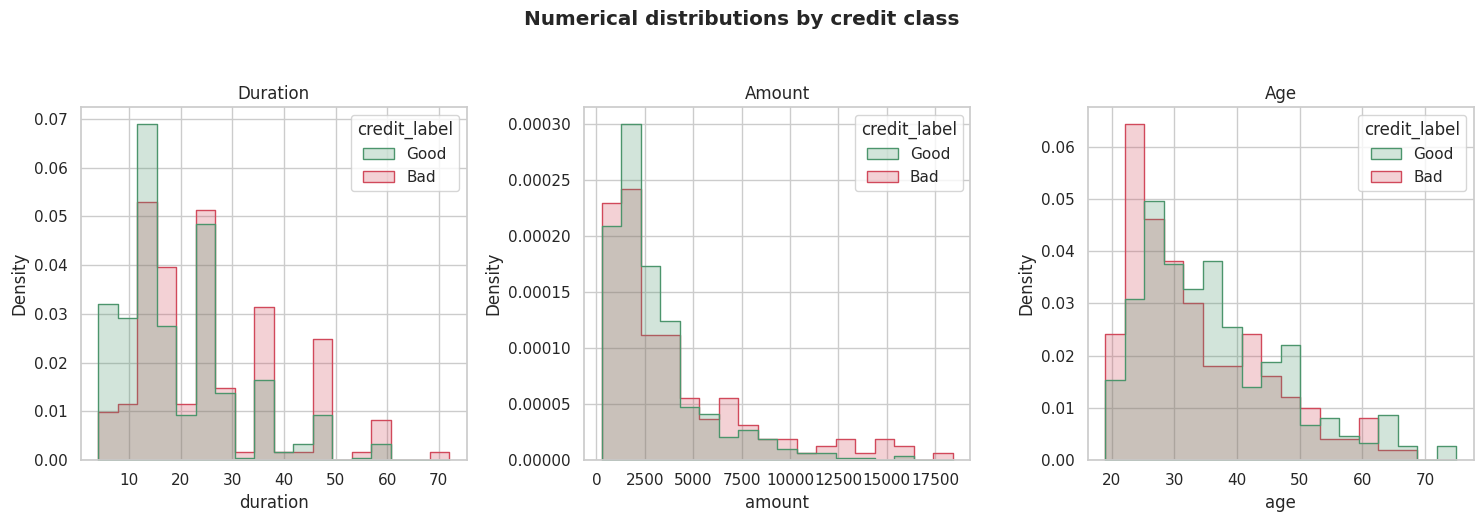

In [ ]:
NUMERIC_FEATURES = ["duration", "amount", "age"]
CATEGORICAL_FEATURES = [c for c in X.columns if c not in NUMERIC_FEATURES]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, feature in zip(axes, NUMERIC_FEATURES):
    sns.histplot(
        data=eda,
        x=feature,
        hue="credit_label",
        hue_order=["Good", "Bad"],
        palette={"Good": "#4C956C", "Bad": "#D1495B"},
        bins=18,
        element="step",
        stat="density",
        common_norm=False,
        ax=ax,
    )
    ax.set_title(feature.replace("_", " ").title())
fig.suptitle("Numerical distributions by credit class", weight="bold", y=1.04)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "eda_numeric_distributions.png", dpi=180, bbox_inches="tight")
plt.show()

,Feature,Bad-rate spread
0,purpose,0.4444
1,status,0.4040
2,credit_history,0.4026
3,savings,0.2419
4,employment_duration,0.2084
5,property,0.1677
6,foreign_worker,0.1574
7,other_debtors,0.1458
8,housing,0.1432
9,job,0.1338


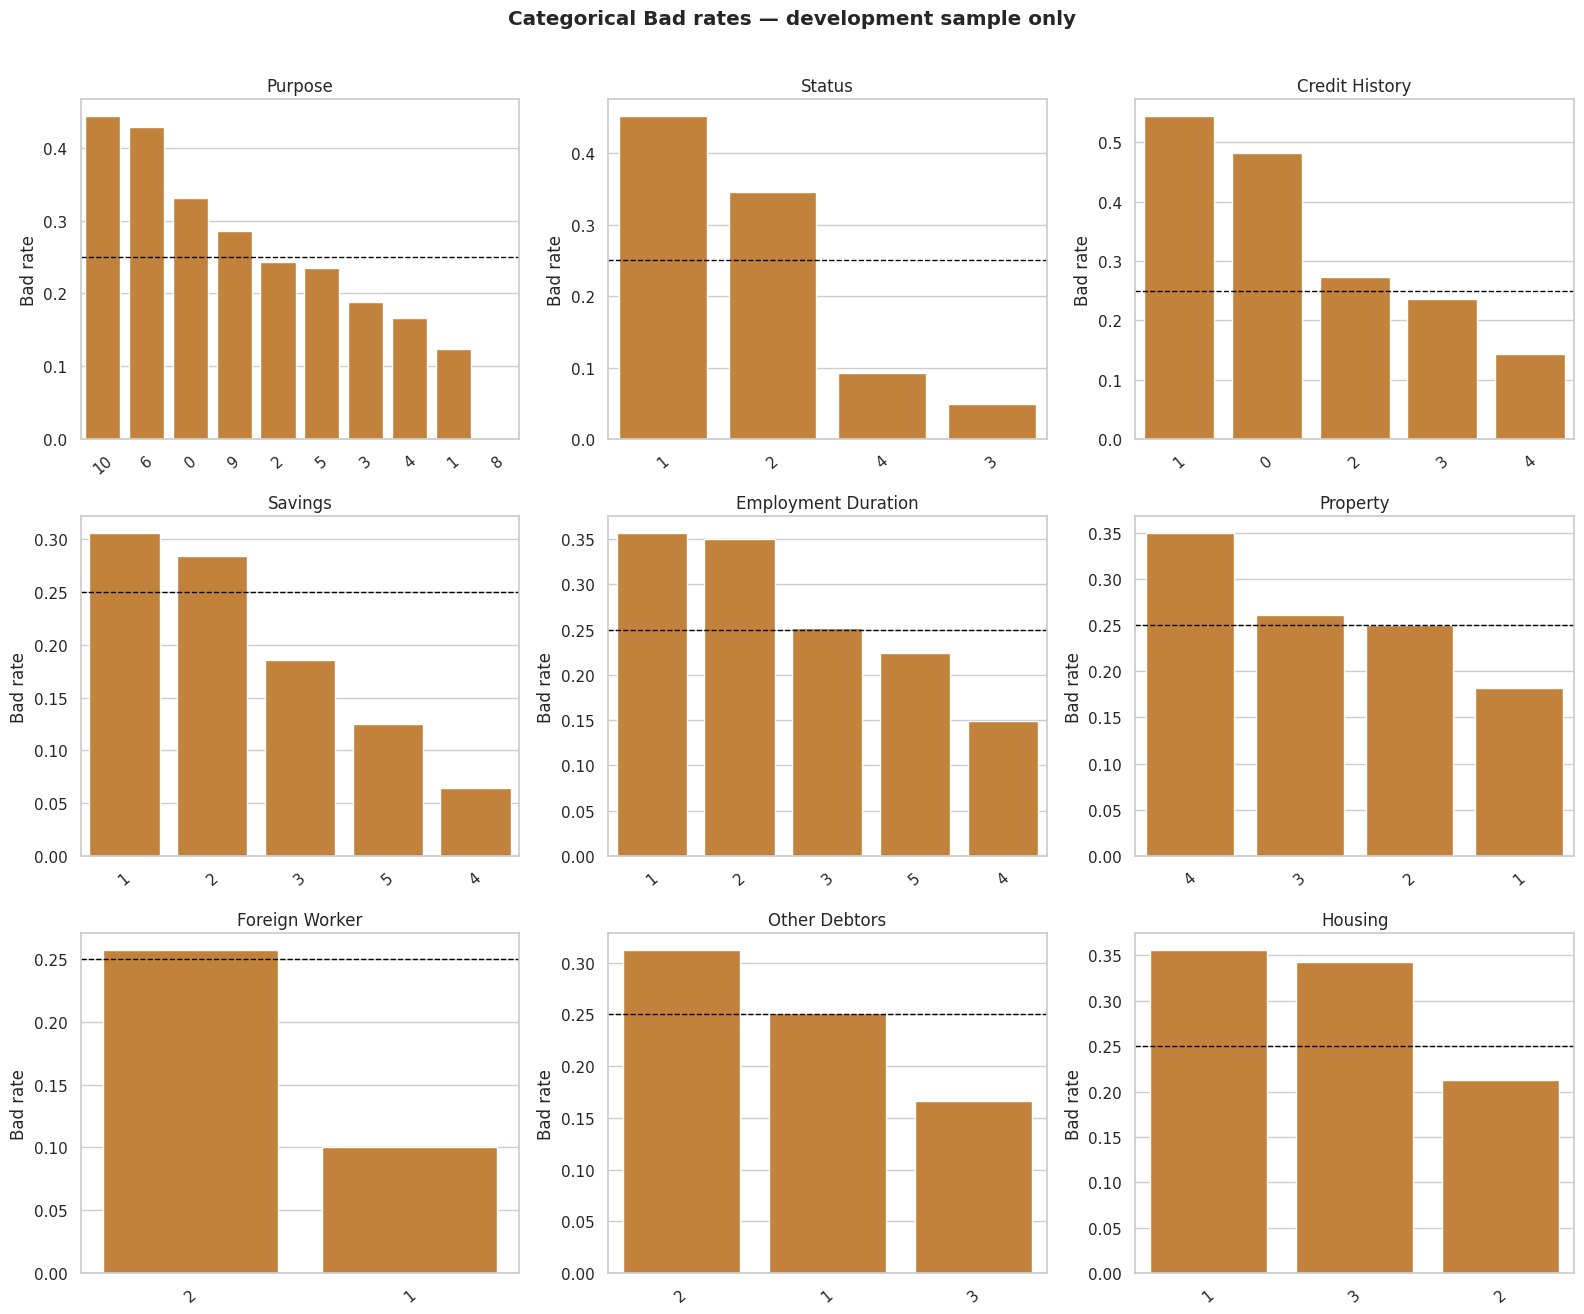

In [ ]:
categorical_rows = []
for feature in CATEGORICAL_FEATURES:
    grouped = (
        eda.groupby(feature, dropna=False)["bad_credit"]
        .agg(["size", "mean"])
        .reset_index()
        .rename(columns={"size": "Count", "mean": "Bad rate"})
    )
    grouped.insert(0, "Feature", feature)
    grouped = grouped.rename(columns={feature: "Category"})
    categorical_rows.append(grouped)

categorical_bad_rates = pd.concat(categorical_rows, ignore_index=True)
categorical_bad_rates.to_csv(OUTPUT_DIR / "eda_categorical_bad_rates.csv", index=False)

rate_spread = (
    categorical_bad_rates.groupby("Feature")["Bad rate"]
    .agg(lambda values: values.max() - values.min())
    .sort_values(ascending=False)
    .rename("Bad-rate spread")
    .reset_index()
)
display(rate_spread)

plot_features = rate_spread.head(9)["Feature"].tolist()
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
for ax, feature in zip(axes.flat, plot_features):
    rows = categorical_bad_rates.query("Feature == @feature").copy()
    rows["Category"] = rows["Category"].astype(str)
    rows = rows.sort_values("Bad rate", ascending=False)
    sns.barplot(data=rows, x="Category", y="Bad rate", color="#D98324", ax=ax)
    ax.axhline(y_dev.mean(), color="black", linestyle="--", linewidth=1)
    ax.set_title(feature.replace("_", " ").title())
    ax.tick_params(axis="x", rotation=40)
    ax.set_xlabel("")
fig.suptitle("Categorical Bad rates — development sample only", weight="bold", y=1.01)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "eda_categorical_bad_rates.png", dpi=180, bbox_inches="tight")
plt.show()

## 5. Predeclared feature-set experiment

The reduced sets are fixed before this notebook sees any new result. They
reflect earlier exploratory low-signal candidates, but this notebook does not
add or remove features after viewing outer-fold performance.

- `Full_20`: all predictors;
- `Drop_2`: remove `telephone` and `people_liable`;
- `Drop_4`: additionally remove `other_debtors` and `job`;
- `Drop_6`: additionally remove `housing` and `property`.

Feature-set selection is treated like a hyperparameter and occurs in inner CV.
Outer validation therefore evaluates the complete feature-selection procedure.

In [ ]:
PREDECLARED_DROPS = {
    "Full_20": [],
    "Drop_2": ["telephone", "people_liable"],
    "Drop_4": ["telephone", "people_liable", "other_debtors", "job"],
    "Drop_6": ["telephone", "people_liable", "other_debtors", "job", "housing", "property"],
}

FEATURE_SETS = []
for name, dropped in PREDECLARED_DROPS.items():
    missing_declared = sorted(set(dropped) - set(X.columns))
    assert not missing_declared, f"Unknown declared features: {missing_declared}"
    kept = [feature for feature in X.columns if feature not in dropped]
    FEATURE_SETS.append({
        "Feature set": name,
        "Dropped features": dropped,
        "Feature columns": kept,
        "Feature count": len(kept),
    })

if SMOKE_TEST:
    FEATURE_SETS = FEATURE_SETS[:2]

feature_set_table = pd.DataFrame([{
    "Feature set": row["Feature set"],
    "Feature count": row["Feature count"],
    "Dropped features": ", ".join(row["Dropped features"]) or "None",
} for row in FEATURE_SETS])
display(feature_set_table)
feature_set_table.to_csv(OUTPUT_DIR / "declared_feature_sets.csv", index=False)

,Feature set,Feature count,Dropped features
0,Full_20,20,None
1,Drop_2,18,"telephone, people_liable"
2,Drop_4,16,"telephone, people_liable, other_debtors, job"
3,Drop_6,14,"telephone, people_liable, other_debtors, job, ..."


## 6. Leakage-safe preprocessing and compact model grid

Duration, amount and age are treated as continuous. All other integer codes
are categorical. Every imputer, scaler, one-hot encoder, optional calibrator
and estimator is fitted inside the relevant CV training fold.

The compact grid avoids over-searching only 640 development observations.

In [ ]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_preprocessor(feature_columns):
    numeric_columns = [feature for feature in NUMERIC_FEATURES if feature in feature_columns]
    categorical_columns = [feature for feature in feature_columns if feature not in numeric_columns]

    transformers = []
    if numeric_columns:
        transformers.append((
            "numeric",
            Pipeline([
                ("impute", SimpleImputer(strategy="median")),
                ("scale", StandardScaler()),
            ]),
            numeric_columns,
        ))
    if categorical_columns:
        transformers.append((
            "categorical",
            Pipeline([
                ("impute", SimpleImputer(strategy="most_frequent")),
                ("encode", make_one_hot_encoder()),
            ]),
            categorical_columns,
        ))
    return ColumnTransformer(transformers=transformers, remainder="drop")


def model_config(family, parameters, calibration="none", complexity=0):
    return {
        "Family": family,
        "Parameters": parameters,
        "Calibration": calibration,
        "Complexity rank": complexity,
    }


MODEL_CONFIGS = []
for C in [0.03, 0.10, 0.30]:
    MODEL_CONFIGS.append(model_config("Logistic Regression", {"C": C, "class_weight": None}, complexity=0))
    MODEL_CONFIGS.append(model_config("Logistic Regression", {"C": C, "class_weight": "balanced"}, complexity=1))

MODEL_CONFIGS.extend([
    model_config("Logistic Regression", {"C": 0.10, "class_weight": None}, calibration="sigmoid", complexity=2),
    model_config("Logistic Regression", {"C": 0.10, "class_weight": "balanced"}, calibration="sigmoid", complexity=2),
    model_config("Gaussian Naive Bayes", {"var_smoothing": 1e-9}, complexity=1),
    model_config("Gaussian Naive Bayes", {"var_smoothing": 1e-3}, complexity=1),
    model_config("Gradient Boosting", {"learning_rate": 0.05, "max_depth": 1}, complexity=3),
    model_config("Gradient Boosting", {"learning_rate": 0.10, "max_depth": 1}, complexity=3),
    model_config("Random Forest", {"max_depth": 5, "min_samples_leaf": 5}, complexity=4),
    model_config("Extra Trees", {"max_depth": 5, "min_samples_leaf": 5}, complexity=4),
])

for number, row in enumerate(MODEL_CONFIGS):
    row["Config ID"] = f"M{number:02d}"

if SMOKE_TEST:
    MODEL_CONFIGS = [MODEL_CONFIGS[1], MODEL_CONFIGS[3], MODEL_CONFIGS[8]]

model_grid_table = pd.DataFrame(MODEL_CONFIGS)
display(model_grid_table)
model_grid_table.to_csv(OUTPUT_DIR / "declared_model_grid.csv", index=False)


def base_estimator(family):
    estimators = {
        "Logistic Regression": LogisticRegression(max_iter=3000, solver="liblinear", random_state=SEED),
        "Gaussian Naive Bayes": GaussianNB(),
        "Gradient Boosting": GradientBoostingClassifier(n_estimators=150, random_state=SEED),
        "Random Forest": RandomForestClassifier(
            n_estimators=300, max_features="sqrt", class_weight="balanced", random_state=SEED, n_jobs=-1
        ),
        "Extra Trees": ExtraTreesClassifier(
            n_estimators=300, max_features="sqrt", class_weight="balanced", random_state=SEED, n_jobs=-1
        ),
    }
    return clone(estimators[family])


def make_candidate_pipeline(feature_columns, candidate):
    estimator = base_estimator(candidate["Family"]).set_params(**candidate["Parameters"])
    if candidate["Calibration"] == "sigmoid":
        estimator = CalibratedClassifierCV(estimator=estimator, method="sigmoid", cv=3)
    return Pipeline([
        ("preprocess", make_preprocessor(feature_columns)),
        ("model", estimator),
    ])


def config_from_id(config_id):
    return next(row for row in MODEL_CONFIGS if row["Config ID"] == config_id)


def feature_set_from_name(name):
    return next(row for row in FEATURE_SETS if row["Feature set"] == name)

,Family,Parameters,Calibration,Complexity rank,Config ID
0,Logistic Regression,"{'C': 0.03, 'class_weight': None}",none,0,M00
1,Logistic Regression,"{'C': 0.03, 'class_weight': 'balanced'}",none,1,M01
2,Logistic Regression,"{'C': 0.1, 'class_weight': None}",none,0,M02
3,Logistic Regression,"{'C': 0.1, 'class_weight': 'balanced'}",none,1,M03
4,Logistic Regression,"{'C': 0.3, 'class_weight': None}",none,0,M04
5,Logistic Regression,"{'C': 0.3, 'class_weight': 'balanced'}",none,1,M05
6,Logistic Regression,"{'C': 0.1, 'class_weight': None}",sigmoid,2,M06
7,Logistic Regression,"{'C': 0.1, 'class_weight': 'balanced'}",sigmoid,2,M07
8,Gaussian Naive Bayes,{'var_smoothing': 1e-09},none,1,M08
9,Gaussian Naive Bayes,{'var_smoothing': 0.001},none,1,M09


## 7. Metrics and robust cost-sensitive threshold selection

A false negative is Actual Bad → Predicted Good. A false positive is Actual
Good → Predicted Bad. The theoretical 5:1 threshold is `1/(5+1)=0.1667` only
under ideal probability calibration.

To reduce sensitivity to a single threshold, the inner-CV rule first finds the
minimum pooled OOF cost, keeps thresholds within 0.01 cost per applicant of
that minimum, and then selects the candidate with the lowest fold-to-fold cost
standard deviation. Remaining ties prefer the theoretical threshold and then
the lower exact cost. This rule is declared before outer evaluation.

In [ ]:
def prediction_metrics(y_true, probabilities, predictions, fn_cost=PRIMARY_FN_COST, fp_cost=PRIMARY_FP_COST):
    y_true = np.asarray(y_true, dtype=int)
    probabilities = np.asarray(probabilities, dtype=float)
    predictions = np.asarray(predictions, dtype=int)
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    total_cost = fn_cost * fn + fp_cost * fp
    prevalence = y_true.mean()
    best_trivial_cost = min(fn_cost * prevalence, fp_cost * (1 - prevalence))
    null_brier = prevalence * (1 - prevalence)
    fpr, tpr, _ = roc_curve(y_true, probabilities)
    brier = brier_score_loss(y_true, probabilities)
    return {
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
        "Cost per applicant": float(total_cost / len(y_true)),
        "Total cost": float(total_cost),
        "Cost reduction vs trivial": float(1 - (total_cost / len(y_true)) / best_trivial_cost),
        "Recall Bad": recall_score(y_true, predictions, zero_division=0),
        "Precision Bad": precision_score(y_true, predictions, zero_division=0),
        "F1 Bad": f1_score(y_true, predictions, zero_division=0),
        "Accuracy": accuracy_score(y_true, predictions),
        "Balanced accuracy": balanced_accuracy_score(y_true, predictions),
        "ROC AUC": roc_auc_score(y_true, probabilities),
        "Average precision": average_precision_score(y_true, probabilities),
        "KS": float(np.max(tpr - fpr)),
        "Brier": brier,
        "Brier skill vs prevalence": float(1 - brier / null_brier),
        "Predicted Bad rate": predictions.mean(),
    }


def score_threshold(y_true, probabilities, threshold, fn_cost=PRIMARY_FN_COST, fp_cost=PRIMARY_FP_COST):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    return {
        "Threshold": float(threshold),
        **prediction_metrics(y_true, probabilities, predictions, fn_cost, fp_cost),
    }


def choose_robust_threshold(y_true, probabilities, validation_positions):
    y_array = np.asarray(y_true, dtype=int)
    probability_array = np.asarray(probabilities, dtype=float)
    theoretical = PRIMARY_FP_COST / (PRIMARY_FN_COST + PRIMARY_FP_COST)
    rows = []

    for threshold in THRESHOLD_GRID:
        pooled = score_threshold(y_array, probability_array, threshold)
        fold_costs = []
        for positions in validation_positions:
            fold_score = score_threshold(
                y_array[positions], probability_array[positions], threshold
            )
            fold_costs.append(fold_score["Cost per applicant"])
        rows.append({
            "Threshold": float(threshold),
            "Cost per applicant": pooled["Cost per applicant"],
            "Fold cost mean": float(np.mean(fold_costs)),
            "Fold cost SD": float(np.std(fold_costs, ddof=1)) if len(fold_costs) > 1 else 0.0,
            "Recall Bad": pooled["Recall Bad"],
            "Precision Bad": pooled["Precision Bad"],
            "Predicted Bad rate": pooled["Predicted Bad rate"],
            "Distance to theoretical": abs(threshold - theoretical),
        })

    curve = pd.DataFrame(rows)
    minimum_cost = curve["Cost per applicant"].min()
    eligible = curve[
        curve["Cost per applicant"] <= minimum_cost + ROBUST_THRESHOLD_TOLERANCE + 1e-12
    ].copy()
    selected = eligible.sort_values(
        ["Fold cost SD", "Distance to theoretical", "Cost per applicant", "Threshold"],
        ascending=[True, True, True, True],
    ).iloc[0]
    return float(selected["Threshold"]), curve, {
        "Minimum cost": float(minimum_cost),
        "Selected cost penalty": float(selected["Cost per applicant"] - minimum_cost),
        "Eligible threshold minimum": float(eligible["Threshold"].min()),
        "Eligible threshold maximum": float(eligible["Threshold"].max()),
        "Eligible threshold width": float(eligible["Threshold"].max() - eligible["Threshold"].min()),
    }

## 8. Inner-CV feature-set, model and threshold search

The search order is declared in advance:

1. lower 5:1 cost;
2. lower threshold-fold cost SD;
3. lower Brier score;
4. higher Average Precision;
5. higher ROC-AUC;
6. fewer raw features;
7. lower declared model complexity.

In [ ]:
def tune_feature_model_candidates(X_train, y_train, seed, keep_probabilities=False):
    splits = list(StratifiedKFold(
        n_splits=INNER_FOLDS,
        shuffle=True,
        random_state=seed,
    ).split(X_train, y_train))
    validation_positions = [validation for _, validation in splits]

    rows = []
    probability_store = {}
    for feature_spec in FEATURE_SETS:
        for candidate in MODEL_CONFIGS:
            pipeline = make_candidate_pipeline(feature_spec["Feature columns"], candidate)
            probabilities = cross_val_predict(
                pipeline,
                X_train,
                y_train,
                cv=splits,
                method="predict_proba",
                n_jobs=1,
            )[:, 1]
            threshold, _, threshold_info = choose_robust_threshold(
                y_train, probabilities, validation_positions
            )
            metrics = score_threshold(y_train, probabilities, threshold)
            key = f"{feature_spec['Feature set']}::{candidate['Config ID']}"
            rows.append({
                "Candidate key": key,
                "Feature set": feature_spec["Feature set"],
                "Feature count": feature_spec["Feature count"],
                "Dropped features": feature_spec["Dropped features"],
                **candidate,
                **metrics,
                "Threshold fold cost SD": float(
                    np.std([
                        score_threshold(
                            y_train.iloc[positions], probabilities[positions], threshold
                        )["Cost per applicant"]
                        for positions in validation_positions
                    ], ddof=1)
                ) if len(validation_positions) > 1 else 0.0,
                **threshold_info,
            })
            if keep_probabilities:
                probability_store[key] = probabilities

    table = pd.DataFrame(rows).sort_values(
        [
            "Cost per applicant", "Threshold fold cost SD", "Brier",
            "Average precision", "ROC AUC", "Feature count", "Complexity rank", "Candidate key",
        ],
        ascending=[True, True, True, False, False, True, True, True],
    ).reset_index(drop=True)

    winner = table.iloc[0].to_dict()
    best_by_feature_set = (
        table.sort_values(
            [
                "Feature set", "Cost per applicant", "Threshold fold cost SD", "Brier",
                "Average precision", "ROC AUC", "Complexity rank", "Candidate key",
            ],
            ascending=[True, True, True, True, False, False, True, True],
        )
        .groupby("Feature set", as_index=False)
        .first()
    )
    return winner, best_by_feature_set, table, probability_store, splits

## 9. Nested cross-validation

For every outer fold, the inner loop selects feature set, model configuration,
calibration and threshold without access to the outer validation rows. The
notebook also evaluates the best inner-selected model within each fixed
feature set for a paired Full-versus-Reduced comparison.

In [ ]:
outer_cv = StratifiedKFold(n_splits=OUTER_FOLDS, shuffle=True, random_state=SEED)
prediction_rows = []
fold_score_rows = []
selection_rows = []
inner_tables = []
permutation_rows = []

for outer_fold, (fit_positions, validation_positions) in enumerate(outer_cv.split(X_dev, y_dev), start=1):
    fold_start = perf_counter()
    X_fit, y_fit = X_dev.iloc[fit_positions], y_dev.iloc[fit_positions]
    X_validation, y_validation = X_dev.iloc[validation_positions], y_dev.iloc[validation_positions]
    assert set(X_fit.index).isdisjoint(X_validation.index)

    winner, best_by_feature_set, inner_table, _, _ = tune_feature_model_candidates(
        X_fit, y_fit, seed=100 + outer_fold, keep_probabilities=False
    )
    inner_table.insert(0, "Outer fold", outer_fold)
    inner_tables.append(inner_table)

    evaluation_specs = [{"Rule": "Nested feature+model selection", **winner}]
    evaluation_specs.extend([
        {"Rule": row["Feature set"], **row.to_dict()}
        for _, row in best_by_feature_set.iterrows()
    ])

    fitted_cache = {}
    for spec in evaluation_specs:
        feature_spec = feature_set_from_name(spec["Feature set"])
        candidate = config_from_id(spec["Config ID"])
        threshold = float(spec["Threshold"])
        cache_key = (spec["Feature set"], spec["Config ID"])

        if cache_key not in fitted_cache:
            fitted_cache[cache_key] = make_candidate_pipeline(
                feature_spec["Feature columns"], candidate
            ).fit(X_fit, y_fit)
        pipeline = fitted_cache[cache_key]
        probabilities = pipeline.predict_proba(X_validation)[:, 1]
        predictions = (probabilities >= threshold).astype(int)
        metrics = prediction_metrics(y_validation, probabilities, predictions)

        fold_score_rows.append({
            "Outer fold": outer_fold,
            "Rule": spec["Rule"],
            "Feature set": spec["Feature set"],
            "Feature count": feature_spec["Feature count"],
            "Selected config": spec["Config ID"],
            "Selected family": candidate["Family"],
            "Calibration": candidate["Calibration"],
            "Threshold": threshold,
            **metrics,
        })
        selection_rows.append({
            "Outer fold": outer_fold,
            "Rule": spec["Rule"],
            "Feature set": spec["Feature set"],
            "Feature count": feature_spec["Feature count"],
            "Dropped features": feature_spec["Dropped features"],
            "Selected config": spec["Config ID"],
            "Selected family": candidate["Family"],
            "Calibration": candidate["Calibration"],
            "Parameters": candidate["Parameters"],
            "Threshold": threshold,
            "Inner cost": spec["Cost per applicant"],
            "Outer cost": metrics["Cost per applicant"],
            "Outer Recall Bad": metrics["Recall Bad"],
            "Elapsed seconds": perf_counter() - fold_start,
        })

        for row_id, actual, probability, prediction in zip(
            X_validation.index, y_validation, probabilities, predictions
        ):
            prediction_rows.append({
                "Id": int(row_id),
                "Outer fold": outer_fold,
                "Rule": spec["Rule"],
                "Actual Bad": int(actual),
                "Probability Bad": float(probability),
                "Predicted Bad": int(prediction),
                "Threshold": threshold,
            })

        # Honest raw-column permutation importance for the Full_20 procedure.
        # It is diagnostic only and never changes FEATURE_SETS in this run.
        if spec["Rule"] == "Full_20":
            rng = np.random.default_rng(SEED + 1000 * outer_fold)
            baseline_cost = metrics["Cost per applicant"]
            baseline_ap = metrics["Average precision"]
            for feature in X.columns:
                for repeat in range(PERMUTATION_REPEATS):
                    permuted = X_validation.copy()
                    permuted[feature] = rng.permutation(permuted[feature].to_numpy())
                    permuted_probability = pipeline.predict_proba(permuted)[:, 1]
                    permuted_prediction = (permuted_probability >= threshold).astype(int)
                    permuted_metrics = prediction_metrics(
                        y_validation, permuted_probability, permuted_prediction
                    )
                    permutation_rows.append({
                        "Outer fold": outer_fold,
                        "Feature": feature,
                        "Repeat": repeat + 1,
                        "Baseline cost": baseline_cost,
                        "Permuted cost": permuted_metrics["Cost per applicant"],
                        "Delta cost": permuted_metrics["Cost per applicant"] - baseline_cost,
                        "Baseline AP": baseline_ap,
                        "Permuted AP": permuted_metrics["Average precision"],
                        "Delta AP": baseline_ap - permuted_metrics["Average precision"],
                    })

    print(
        f"Outer fold {outer_fold}/{OUTER_FOLDS}: selected {winner['Feature set']} + "
        f"{winner['Family']} ({winner['Config ID']}), threshold={winner['Threshold']:.2f}; "
        f"elapsed={perf_counter() - fold_start:.1f}s"
    )

outer_predictions = pd.DataFrame(prediction_rows)
outer_fold_scores = pd.DataFrame(fold_score_rows)
selection_history = pd.DataFrame(selection_rows)
all_inner_search = pd.concat(inner_tables, ignore_index=True)
raw_permutation = pd.DataFrame(permutation_rows)

outer_predictions.to_csv(OUTPUT_DIR / "outer_predictions.csv", index=False)
outer_fold_scores.to_csv(OUTPUT_DIR / "outer_fold_scores.csv", index=False)
selection_history.to_csv(OUTPUT_DIR / "selection_history.csv", index=False)
all_inner_search.to_csv(OUTPUT_DIR / "inner_search_all_outer_folds.csv", index=False)
raw_permutation.to_csv(OUTPUT_DIR / "raw_feature_permutation_repeats.csv", index=False)

display(selection_history.query("Rule == 'Nested feature+model selection'"))

Outer fold 1/5: selected Full_20 + Logistic Regression (M06), threshold=0.21; elapsed=228.9s
Outer fold 2/5: selected Drop_6 + Logistic Regression (M04), threshold=0.18; elapsed=228.3s
Outer fold 3/5: selected Drop_6 + Extra Trees (M13), threshold=0.40; elapsed=224.7s
Outer fold 4/5: selected Drop_2 + Logistic Regression (M01), threshold=0.41; elapsed=227.9s
Outer fold 5/5: selected Drop_6 + Extra Trees (M13), threshold=0.43; elapsed=243.7s


,Outer fold,Rule,Feature set,Feature count,Dropped features,Selected config,Selected family,Calibration,Parameters,Threshold,Inner cost,Outer cost,Outer Recall Bad,Elapsed seconds
0,1,Nested feature+model selection,Full_20,20,[],M06,Logistic Regression,sigmoid,"{'C': 0.1, 'class_weight': None}",0.21,0.4883,0.6953,0.6562,222.2385
5,2,Nested feature+model selection,Drop_6,14,"[telephone, people_liable, other_debtors, job,...",M04,Logistic Regression,none,"{'C': 0.3, 'class_weight': None}",0.18,0.4707,0.4766,0.9062,222.2383
10,3,Nested feature+model selection,Drop_6,14,"[telephone, people_liable, other_debtors, job,...",M13,Extra Trees,none,"{'max_depth': 5, 'min_samples_leaf': 5}",0.40,0.4883,0.4844,0.8750,217.1421
15,4,Nested feature+model selection,Drop_2,18,"[telephone, people_liable]",M01,Logistic Regression,none,"{'C': 0.03, 'class_weight': 'balanced'}",0.41,0.5176,0.6406,0.7812,221.6608
20,5,Nested feature+model selection,Drop_6,14,"[telephone, people_liable, other_debtors, job,...",M13,Extra Trees,none,"{'max_depth': 5, 'min_samples_leaf': 5}",0.43,0.4453,0.7031,0.7188,214.1607


## 10. Aggregate outer-CV evidence

The `Nested feature+model selection` row is the primary estimate of the whole
procedure. Fixed feature-set rows are paired, descriptive experiments. They do
not authorize a post-hoc switch after seeing outer results.

In [ ]:
comparison_rows = []
for rule, rows in outer_predictions.groupby("Rule", sort=False):
    assert rows["Id"].nunique() == len(y_dev)
    ordered = rows.sort_values("Id")
    metrics = prediction_metrics(
        ordered["Actual Bad"],
        ordered["Probability Bad"],
        ordered["Predicted Bad"],
    )
    fold_subset = outer_fold_scores.query("Rule == @rule")
    comparison_rows.append({
        "Rule": rule,
        **metrics,
        "Outer cost SD": fold_subset["Cost per applicant"].std(),
        "Outer Recall SD": fold_subset["Recall Bad"].std(),
        "Threshold mean": fold_subset["Threshold"].mean(),
        "Threshold SD": fold_subset["Threshold"].std(),
    })

outer_comparison = pd.DataFrame(comparison_rows).sort_values(
    ["Cost per applicant", "Outer cost SD", "Brier", "Average precision"],
    ascending=[True, True, True, False],
).reset_index(drop=True)
outer_comparison.to_csv(OUTPUT_DIR / "outer_feature_set_comparison.csv", index=False)

display(outer_comparison[[
    "Rule", "Cost per applicant", "Cost reduction vs trivial", "Outer cost SD",
    "Recall Bad", "Precision Bad", "F1 Bad", "Average precision", "ROC AUC",
    "KS", "Brier", "Brier skill vs prevalence", "Predicted Bad rate",
    "Threshold mean", "Threshold SD",
]])

,Rule,Cost per applicant,Cost reduction vs trivial,Outer cost SD,Recall Bad,Precision Bad,F1 Bad,Average precision,ROC AUC,KS,Brier,Brier skill vs prevalence,Predicted Bad rate,Threshold mean,Threshold SD
0,Drop_4,0.5563,0.2583,0.0772,0.8125,0.3869,0.5242,0.4714,0.7221,0.3313,0.1736,0.0739,0.5250,0.278,0.1134
1,Drop_2,0.5844,0.2208,0.1393,0.7812,0.3858,0.5165,0.4860,0.7314,0.3458,0.1791,0.0447,0.5062,0.332,0.1105
2,Nested feature+model selection,0.6000,0.2000,0.1118,0.7875,0.3706,0.5040,0.5050,0.7347,0.3667,0.1791,0.0447,0.5312,0.326,0.1205
3,Full_20,0.6000,0.2000,0.1568,0.7688,0.3820,0.5104,0.4999,0.7259,0.3396,0.1767,0.0576,0.5031,0.308,0.1295
4,Drop_6,0.6203,0.1729,0.1336,0.7625,0.3708,0.4990,0.4415,0.7177,0.3750,0.2112,-0.1266,0.5141,0.318,0.1618


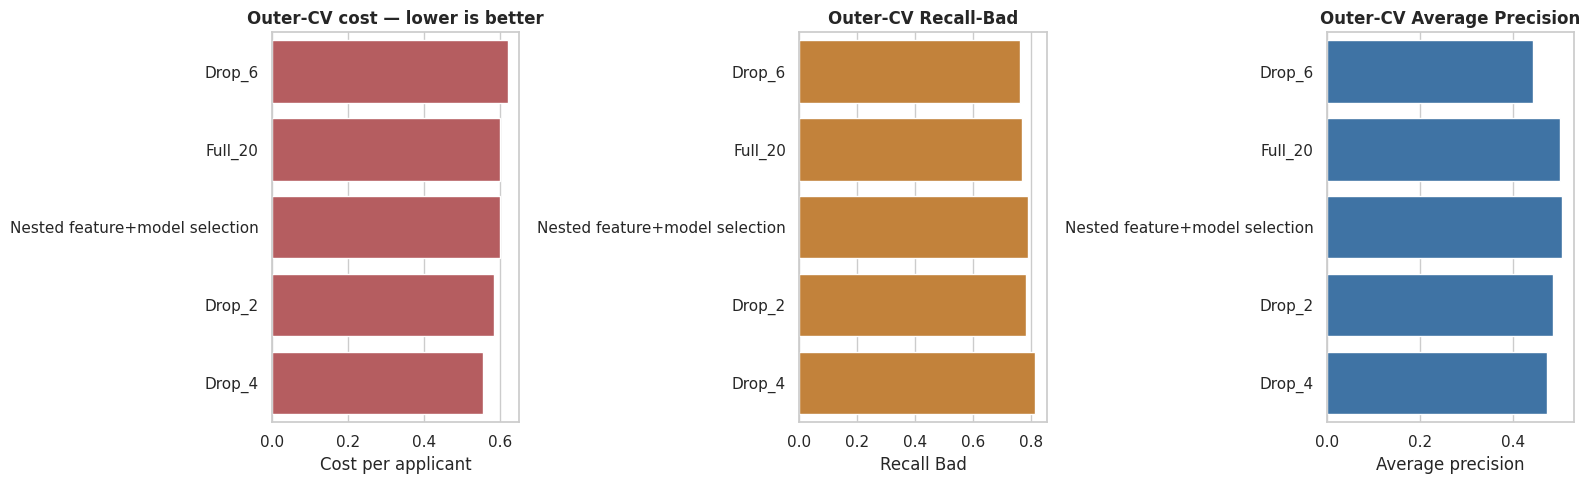

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_order = outer_comparison.sort_values("Cost per applicant", ascending=False)
sns.barplot(data=plot_order, x="Cost per applicant", y="Rule", color="#C44E52", ax=axes[0])
axes[0].set_title("Outer-CV cost — lower is better", weight="bold")
sns.barplot(data=plot_order, x="Recall Bad", y="Rule", color="#D98324", ax=axes[1])
axes[1].set_title("Outer-CV Recall-Bad", weight="bold")
sns.barplot(data=plot_order, x="Average precision", y="Rule", color="#2E74B5", ax=axes[2])
axes[2].set_title("Outer-CV Average Precision", weight="bold")
for ax in axes:
    ax.set_ylabel("")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "outer_feature_set_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

## 11. Paired Full-versus-Reduced comparison

Because every rule uses the same outer folds, cost and Recall differences can
be compared fold by fold. A reduced set is labelled `Promising improvement`
only if it lowers mean cost, does not reduce mean Recall-Bad by more than two
percentage points and wins on at least three of five folds. This label remains
descriptive; the final rule is still selected from development inner CV.

In [ ]:
full_fold = outer_fold_scores.query("Rule == 'Full_20'").set_index("Outer fold")
paired_rows = []
for feature_spec in FEATURE_SETS:
    rule = feature_spec["Feature set"]
    if rule == "Full_20":
        continue
    reduced_fold = outer_fold_scores.query("Rule == @rule").set_index("Outer fold")
    paired = reduced_fold.join(
        full_fold[["Cost per applicant", "Recall Bad"]],
        how="inner",
        lsuffix=" Reduced",
        rsuffix=" Full",
    )
    delta_cost = paired["Cost per applicant Reduced"] - paired["Cost per applicant Full"]
    delta_recall = paired["Recall Bad Reduced"] - paired["Recall Bad Full"]
    wins = int((delta_cost < 0).sum())
    non_worse = int((delta_cost <= 0).sum())
    if delta_cost.mean() < 0 and delta_recall.mean() >= -0.02 and wins >= max(2, OUTER_FOLDS // 2 + 1):
        decision = "Promising improvement"
    elif delta_cost.mean() <= 0.01 and delta_recall.mean() >= -0.02:
        decision = "Comparable and simpler"
    else:
        decision = "No evidence to prefer"
    paired_rows.append({
        "Reduced feature set": rule,
        "Features removed": 20 - feature_spec["Feature count"],
        "Mean delta cost (Reduced - Full)": delta_cost.mean(),
        "Median delta cost": delta_cost.median(),
        "Mean delta Recall Bad": delta_recall.mean(),
        "Cost wins": wins,
        "Cost non-worse folds": non_worse,
        "Outer folds": OUTER_FOLDS,
        "Decision": decision,
    })

paired_feature_comparison = pd.DataFrame(paired_rows).sort_values(
    "Mean delta cost (Reduced - Full)"
)
display(paired_feature_comparison)
paired_feature_comparison.to_csv(OUTPUT_DIR / "paired_full_vs_reduced.csv", index=False)

,Reduced feature set,Features removed,Mean delta cost (Reduced - Full),Median delta cost,Mean delta Recall Bad,Cost wins,Cost non-worse folds,Outer folds,Decision
1,Drop_4,4,-0.0437,-0.0078,0.0437,3,3,5,Promising improvement
0,Drop_2,2,-0.0156,0.0000,0.0125,2,3,5,Comparable and simpler
2,Drop_6,6,0.0203,0.0156,-0.0063,1,2,5,No evidence to prefer


## 12. Raw-feature permutation importance

Positive `Mean delta cost` means shuffling the feature increases cost and the
fitted model relied on that feature. Values near zero are weak evidence, not an
automatic instruction to drop the feature. Correlated variables can share or
hide importance. These results are diagnostic and do not alter this run.

,Feature,Mean delta cost,SD delta cost,Positive-cost fraction,Mean delta AP
18,status,0.1792,0.1374,0.91,0.1354
3,duration,0.0210,0.0777,0.55,0.0435
0,age,0.0098,0.0342,0.52,-0.0162
8,job,0.0056,0.0366,0.40,0.0036
9,number_credits,0.0047,0.0355,0.38,0.0053
5,foreign_worker,0.0040,0.0153,0.22,0.0019
17,savings,-0.0009,0.0599,0.51,0.0354
12,people_liable,-0.0020,0.0054,0.04,-0.0007
6,housing,-0.0034,0.0390,0.44,-0.0030
10,other_debtors,-0.0061,0.0212,0.21,0.0038


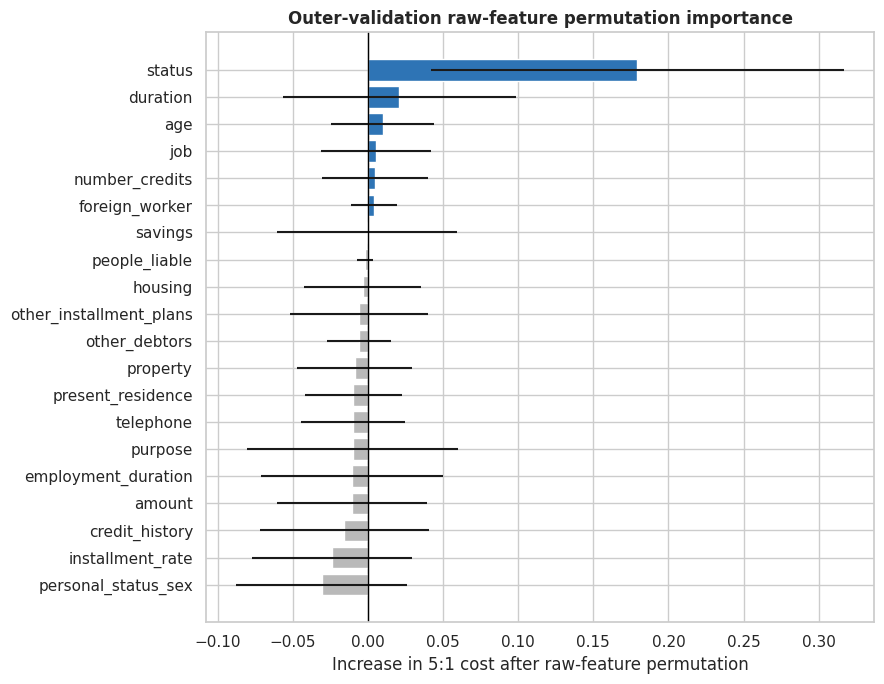

In [ ]:
permutation_importance = (
    raw_permutation.groupby("Feature", as_index=False)
    .agg(
        **{
            "Mean delta cost": ("Delta cost", "mean"),
            "SD delta cost": ("Delta cost", "std"),
            "Positive-cost fraction": ("Delta cost", lambda values: np.mean(values > 0)),
            "Mean delta AP": ("Delta AP", "mean"),
        }
    )
    .sort_values(["Mean delta cost", "Mean delta AP"], ascending=[False, False])
)
display(permutation_importance)
permutation_importance.to_csv(OUTPUT_DIR / "raw_feature_permutation_importance.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 7))
plot_importance = permutation_importance.sort_values("Mean delta cost")
ax.barh(
    plot_importance["Feature"],
    plot_importance["Mean delta cost"],
    xerr=plot_importance["SD delta cost"].fillna(0),
    color=np.where(plot_importance["Mean delta cost"] >= 0, "#2E74B5", "#B9B9B9"),
)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Increase in 5:1 cost after raw-feature permutation")
ax.set_title("Outer-validation raw-feature permutation importance", weight="bold")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "raw_feature_permutation_importance.png", dpi=180, bbox_inches="tight")
plt.show()

## 13. Threshold, ranking and calibration stability

These figures diagnose the already evaluated outer predictions and do not
trigger a new model choice.

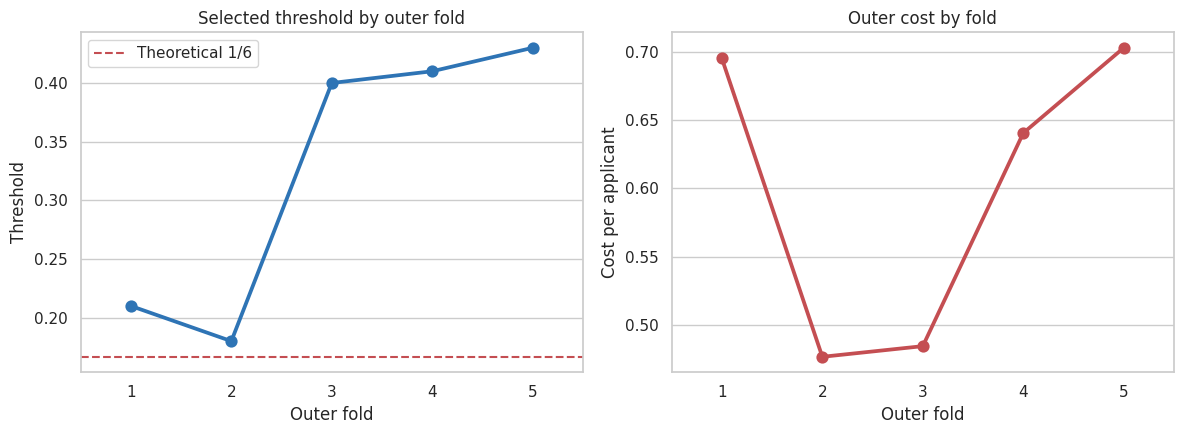

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.pointplot(
    data=outer_fold_scores.query("Rule == 'Nested feature+model selection'"),
    x="Outer fold", y="Threshold", color="#2E74B5", ax=axes[0],
)
axes[0].axhline(1 / 6, color="#C44E52", linestyle="--", label="Theoretical 1/6")
axes[0].set_title("Selected threshold by outer fold")
axes[0].legend()
sns.pointplot(
    data=outer_fold_scores.query("Rule == 'Nested feature+model selection'"),
    x="Outer fold", y="Cost per applicant", color="#C44E52", ax=axes[1],
)
axes[1].set_title("Outer cost by fold")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "nested_threshold_cost_stability.png", dpi=180, bbox_inches="tight")
plt.show()

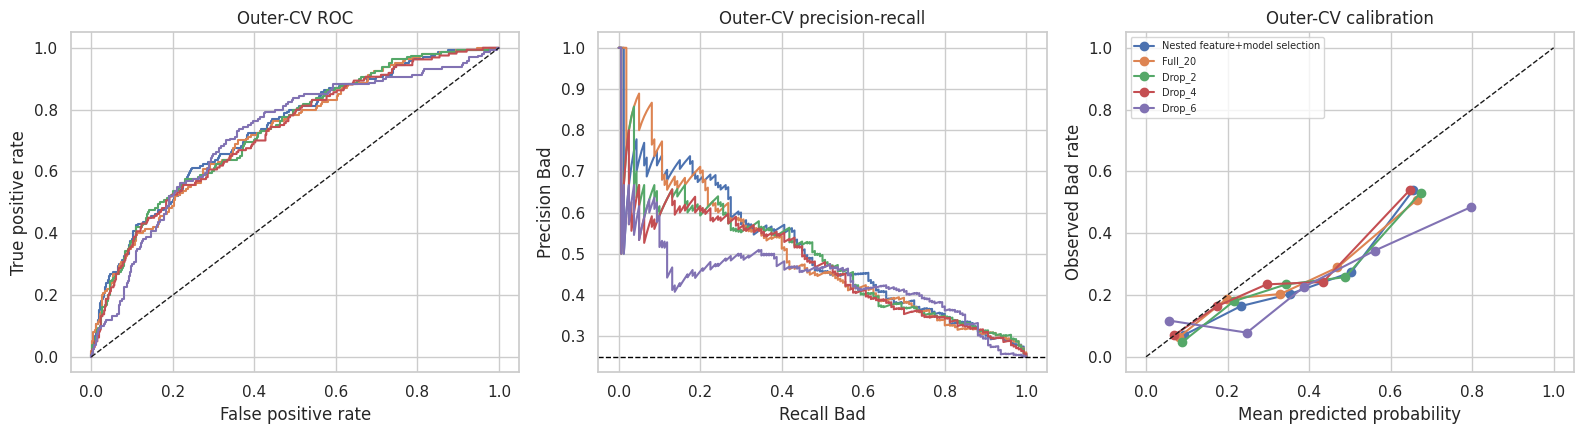

In [ ]:
diagnostic_rules = ["Nested feature+model selection", "Full_20"]
diagnostic_rules.extend([spec["Feature set"] for spec in FEATURE_SETS if spec["Feature set"] != "Full_20"])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for rule in diagnostic_rules:
    rows = outer_predictions.query("Rule == @rule").sort_values("Id")
    fpr, tpr, _ = roc_curve(rows["Actual Bad"], rows["Probability Bad"])
    precision, recall, _ = precision_recall_curve(rows["Actual Bad"], rows["Probability Bad"])
    observed, mean_probability = calibration_curve(
        rows["Actual Bad"], rows["Probability Bad"], n_bins=5, strategy="quantile"
    )
    axes[0].plot(fpr, tpr, label=rule)
    axes[1].plot(recall, precision, label=rule)
    axes[2].plot(mean_probability, observed, "o-", label=rule)

axes[0].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[1].axhline(y_dev.mean(), color="black", linestyle="--", linewidth=1)
axes[2].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[0].set(xlabel="False positive rate", ylabel="True positive rate", title="Outer-CV ROC")
axes[1].set(xlabel="Recall Bad", ylabel="Precision Bad", title="Outer-CV precision-recall")
axes[2].set(xlabel="Mean predicted probability", ylabel="Observed Bad rate", title="Outer-CV calibration")
axes[2].legend(fontsize=7)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "outer_ranking_calibration.png", dpi=180, bbox_inches="tight")
plt.show()

## 14. Freeze the final rule from all development rows

This repeats the same inner-CV selection rule on all 640 development rows.
Outer results and benchmark labels are not inputs to this selection.

In [ ]:
final_winner, final_best_by_set, final_search, final_probability_store, final_splits = tune_feature_model_candidates(
    X_dev, y_dev, seed=1000, keep_probabilities=True
)
final_search.to_csv(OUTPUT_DIR / "final_development_search.csv", index=False)
display(final_search.head(20))

FINAL_FEATURE_SPEC = feature_set_from_name(final_winner["Feature set"])
FINAL_CONFIG = config_from_id(final_winner["Config ID"])
FINAL_THRESHOLD = float(final_winner["Threshold"])
FINAL_KEY = final_winner["Candidate key"]
final_oof_probability = final_probability_store[FINAL_KEY]
development_pipeline = make_candidate_pipeline(
    FINAL_FEATURE_SPEC["Feature columns"], FINAL_CONFIG
).fit(X_dev, y_dev)

print("Frozen feature set:", FINAL_FEATURE_SPEC["Feature set"])
print("Dropped features:", FINAL_FEATURE_SPEC["Dropped features"] or "None")
print("Frozen family:", FINAL_CONFIG["Family"])
print("Frozen parameters:", FINAL_CONFIG["Parameters"])
print("Frozen calibration:", FINAL_CONFIG["Calibration"])
print("Frozen threshold:", round(FINAL_THRESHOLD, 3))

,Candidate key,Feature set,Feature count,Dropped features,Family,Parameters,Calibration,Complexity rank,Config ID,Threshold,TN,FP,FN,TP,Cost per applicant,Total cost,Cost reduction vs trivial,Recall Bad,Precision Bad,F1 Bad,Accuracy,Balanced accuracy,ROC AUC,Average precision,KS,Brier,Brier skill vs prevalence,Predicted Bad rate,Threshold fold cost SD,Minimum cost,Selected cost penalty,Eligible threshold minimum,Eligible threshold maximum,Eligible threshold width
0,Drop_6::M12,Drop_6,14,"[telephone, people_liable, other_debtors, job,...",Random Forest,"{'max_depth': 5, 'min_samples_leaf': 5}",none,4,M12,0.43,308,172,24,136,0.4562,292.0,0.3917,0.8500,0.4416,0.5812,0.6937,0.7458,0.7883,0.5237,0.4917,0.1820,0.0291,0.4813,0.0950,0.4562,0.0000,0.43,0.43,0.00
1,Drop_4::M12,Drop_4,16,"[telephone, people_liable, other_debtors, job]",Random Forest,"{'max_depth': 5, 'min_samples_leaf': 5}",none,4,M12,0.44,322,158,27,133,0.4578,293.0,0.3896,0.8313,0.4570,0.5898,0.7109,0.7510,0.7862,0.5182,0.5042,0.1848,0.0146,0.4547,0.0862,0.4578,0.0000,0.44,0.44,0.00
2,Drop_6::M05,Drop_6,14,"[telephone, people_liable, other_debtors, job,...",Logistic Regression,"{'C': 0.3, 'class_weight': 'balanced'}",none,1,M05,0.40,313,167,28,132,0.4797,307.0,0.3604,0.8250,0.4415,0.5752,0.6953,0.7385,0.7936,0.5577,0.4896,0.1791,0.0449,0.4672,0.0611,0.4797,0.0000,0.40,0.40,0.00
3,Full_20::M03,Full_20,20,[],Logistic Regression,"{'C': 0.1, 'class_weight': 'balanced'}",none,1,M03,0.40,293,187,24,136,0.4797,307.0,0.3604,0.8500,0.4211,0.5631,0.6703,0.7302,0.7879,0.5509,0.4938,0.1822,0.0280,0.5047,0.0669,0.4797,0.0000,0.40,0.46,0.06
4,Full_20::M01,Full_20,20,[],Logistic Regression,"{'C': 0.03, 'class_weight': 'balanced'}",none,1,M01,0.44,292,188,24,136,0.4813,308.0,0.3583,0.8500,0.4198,0.5620,0.6687,0.7292,0.7841,0.5383,0.4771,0.1924,-0.0259,0.5062,0.0857,0.4813,0.0000,0.43,0.46,0.03
5,Full_20::M12,Full_20,20,[],Random Forest,"{'max_depth': 5, 'min_samples_leaf': 5}",none,4,M12,0.43,312,168,28,132,0.4813,308.0,0.3583,0.8250,0.4400,0.5739,0.6937,0.7375,0.7807,0.5020,0.4833,0.1859,0.0087,0.4688,0.0862,0.4781,0.0031,0.41,0.43,0.02
6,Drop_2::M11,Drop_2,18,"[telephone, people_liable]",Gradient Boosting,"{'learning_rate': 0.1, 'max_depth': 1}",none,3,M11,0.17,261,219,18,142,0.4828,309.0,0.3563,0.8875,0.3934,0.5451,0.6297,0.7156,0.7751,0.4880,0.4563,0.1562,0.1668,0.5641,0.0604,0.4828,0.0000,0.17,0.17,0.00
7,Full_20::M11,Full_20,20,[],Gradient Boosting,"{'learning_rate': 0.1, 'max_depth': 1}",none,3,M11,0.17,261,219,18,142,0.4828,309.0,0.3563,0.8875,0.3934,0.5451,0.6297,0.7156,0.7751,0.4880,0.4563,0.1562,0.1668,0.5641,0.0604,0.4828,0.0000,0.17,0.17,0.00
8,Drop_2::M12,Drop_2,18,"[telephone, people_liable]",Random Forest,"{'max_depth': 5, 'min_samples_leaf': 5}",none,4,M12,0.42,301,179,26,134,0.4828,309.0,0.3563,0.8375,0.4281,0.5666,0.6797,0.7323,0.7823,0.5002,0.4917,0.1840,0.0187,0.4891,0.0883,0.4781,0.0047,0.40,0.44,0.04
9,Drop_6::M11,Drop_6,14,"[telephone, people_liable, other_debtors, job,...",Gradient Boosting,"{'learning_rate': 0.1, 'max_depth': 1}",none,3,M11,0.18,279,201,22,138,0.4859,311.0,0.3521,0.8625,0.4071,0.5531,0.6516,0.7219,0.7777,0.4999,0.4563,0.1547,0.1747,0.5297,0.0277,0.4859,0.0000,0.18,0.19,0.01


Frozen feature set: Drop_6
Dropped features: ['telephone', 'people_liable', 'other_debtors', 'job', 'housing', 'property']
Frozen family: Random Forest
Frozen parameters: {'max_depth': 5, 'min_samples_leaf': 5}
Frozen calibration: none
Frozen threshold: 0.43


,Minimum cost,Selected cost penalty,Eligible threshold minimum,Eligible threshold maximum,Eligible threshold width
0,0.4562,0.0,0.43,0.43,0.0


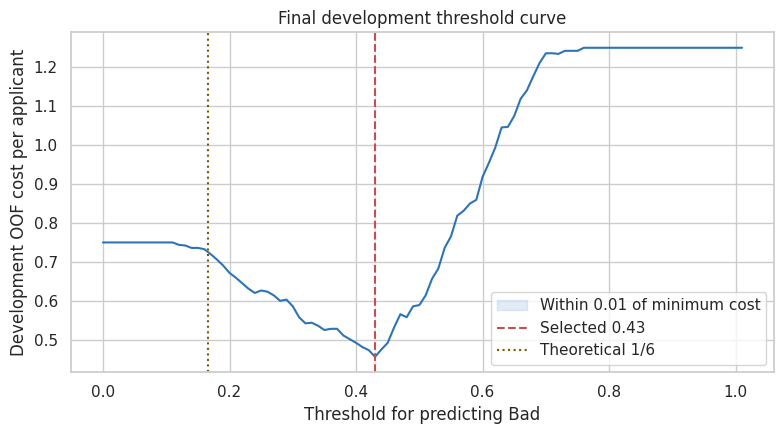

In [ ]:
final_validation_positions = [validation for _, validation in final_splits]
_, final_threshold_curve, final_threshold_info = choose_robust_threshold(
    y_dev, final_oof_probability, final_validation_positions
)
final_threshold_curve.to_csv(OUTPUT_DIR / "final_threshold_curve.csv", index=False)
pd.DataFrame([final_threshold_info]).to_csv(OUTPUT_DIR / "final_threshold_plateau.csv", index=False)
display(pd.DataFrame([final_threshold_info]))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(final_threshold_curve["Threshold"], final_threshold_curve["Cost per applicant"], color="#2E74B5")
ax.axvspan(
    final_threshold_info["Eligible threshold minimum"],
    final_threshold_info["Eligible threshold maximum"],
    color="#A7C7E7", alpha=0.35, label="Within 0.01 of minimum cost",
)
ax.axvline(FINAL_THRESHOLD, color="#C44E52", linestyle="--", label=f"Selected {FINAL_THRESHOLD:.2f}")
ax.axvline(1 / 6, color="#7A5A00", linestyle=":", label="Theoretical 1/6")
ax.set(
    xlabel="Threshold for predicting Bad",
    ylabel="Development OOF cost per applicant",
    title="Final development threshold curve",
)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "final_threshold_curve.png", dpi=180, bbox_inches="tight")
plt.show()

## 15. Frozen historical-benchmark evaluation

No feature set, model, hyperparameter, calibration or threshold changes after
this cell. Because the benchmark has been inspected in earlier project work,
this is a transparent diagnostic check rather than a new independent test.

,Rule,Threshold,TN,FP,FN,TP,Cost per applicant,Total cost,Cost reduction vs trivial,Recall Bad,Precision Bad,F1 Bad,Accuracy,Balanced accuracy,ROC AUC,Average precision,KS,Brier,Brier skill vs prevalence,Predicted Bad rate
0,Frozen cost-sensitive rule,0.43,74,46,10,30,0.6000,96.0,0.2000,0.750,0.3947,0.5172,0.6500,0.6833,0.7321,0.4508,0.4083,0.1938,-0.0337,0.4750
1,Same model at threshold 0.50,0.50,90,30,17,23,0.7188,115.0,0.0417,0.575,0.4340,0.4946,0.7063,0.6625,0.7321,0.4508,0.4083,0.1938,-0.0337,0.3312


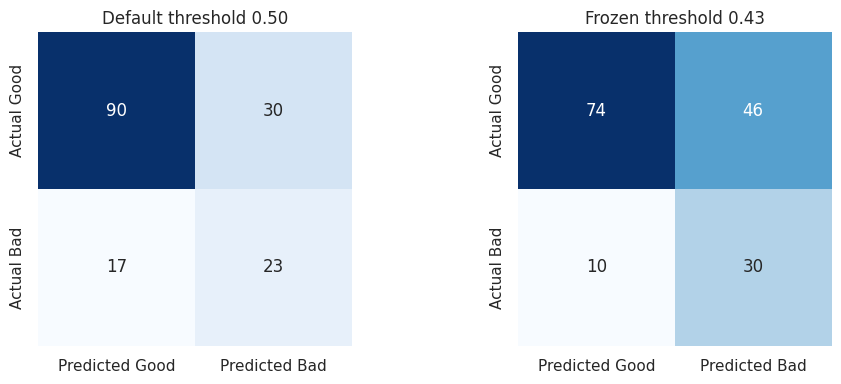

In [ ]:
benchmark_probability = development_pipeline.predict_proba(X_benchmark)[:, 1]
benchmark_rows = []
for label, threshold in [
    ("Frozen cost-sensitive rule", FINAL_THRESHOLD),
    ("Same model at threshold 0.50", 0.50),
]:
    benchmark_rows.append({
        "Rule": label,
        **score_threshold(y_benchmark, benchmark_probability, threshold),
    })

benchmark_results = pd.DataFrame(benchmark_rows)
display(benchmark_results)
benchmark_results.to_csv(OUTPUT_DIR / "historical_benchmark_results.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, threshold, title in zip(
    axes,
    [0.50, FINAL_THRESHOLD],
    ["Default threshold 0.50", f"Frozen threshold {FINAL_THRESHOLD:.2f}"],
):
    matrix = confusion_matrix(y_benchmark, benchmark_probability >= threshold, labels=[0, 1])
    sns.heatmap(
        matrix, annot=True, fmt="d", cmap="Blues", cbar=False, square=True,
        xticklabels=["Predicted Good", "Predicted Bad"],
        yticklabels=["Actual Good", "Actual Bad"], ax=ax,
    )
    ax.set_title(title)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "historical_confusion_matrices.png", dpi=180, bbox_inches="tight")
plt.show()

## 16. Refit the frozen rule and create competition predictions

Only after the rule is frozen do the 160 benchmark rows join the training set.
Competition labels are unknown and are never reconstructed from public data.

In [ ]:
final_pipeline = make_candidate_pipeline(
    FINAL_FEATURE_SPEC["Feature columns"], FINAL_CONFIG
).fit(X, y)
competition_probability = final_pipeline.predict_proba(competition)[:, 1]
competition_predicted_bad = (competition_probability >= FINAL_THRESHOLD).astype(int)

submission = pd.DataFrame({
    "Id": competition.index,
    "kredit": 1 - competition_predicted_bad,
})
risk_scores = pd.DataFrame({
    "Id": competition.index,
    "probability_bad": competition_probability,
    "predicted_bad": competition_predicted_bad,
    "predicted_kredit": 1 - competition_predicted_bad,
})

assert submission.shape == (len(competition), 2)
assert submission["kredit"].isin([0, 1]).all()
submission.to_csv(OUTPUT_DIR / "submission_cost_sensitive.csv", index=False)
risk_scores.to_csv(OUTPUT_DIR / "competition_risk_scores.csv", index=False)
joblib.dump({
    "pipeline": final_pipeline,
    "threshold": FINAL_THRESHOLD,
    "positive_class": "Bad credit",
    "fn_cost": PRIMARY_FN_COST,
    "fp_cost": PRIMARY_FP_COST,
    "feature_set": FINAL_FEATURE_SPEC,
    "configuration": FINAL_CONFIG,
    "all_raw_feature_columns": X.columns.tolist(),
}, OUTPUT_DIR / "german_credit_feature_selected_model.joblib")

display(submission.head())
print("Competition predicted Bad:", int(competition_predicted_bad.sum()), "/", len(competition))

,Id,kredit
0,4,0
1,14,0
2,18,0
3,20,1
4,22,0


Competition predicted Bad: 131 / 200


## 17. Automatic interpretation and run manifest

This cell prints the result that should be sent back for review. It explicitly
distinguishes honest outer-CV evidence, paired feature-set diagnostics and the
previously inspected benchmark.

In [ ]:
nested_outer = outer_comparison.loc[
    outer_comparison["Rule"] == "Nested feature+model selection"
].iloc[0]
full_outer = outer_comparison.loc[outer_comparison["Rule"] == "Full_20"].iloc[0]
frozen_benchmark = benchmark_results.loc[
    benchmark_results["Rule"] == "Frozen cost-sensitive rule"
].iloc[0]

if paired_feature_comparison.empty:
    best_reduced_message = "No reduced feature set was evaluated."
else:
    best_reduced = paired_feature_comparison.iloc[0]
    best_reduced_message = (
        f"Best paired reduced experiment: {best_reduced['Reduced feature set']}; "
        f"mean delta cost={best_reduced['Mean delta cost (Reduced - Full)']:.3f}, "
        f"mean delta Recall-Bad={best_reduced['Mean delta Recall Bad']:.3f}, "
        f"decision={best_reduced['Decision']}."
    )

print("FINAL INTERPRETATION")
print("=" * 88)
print(
    f"The complete nested feature+model procedure achieved outer-CV cost "
    f"{nested_outer['Cost per applicant']:.3f} ± {nested_outer['Outer cost SD']:.3f}, "
    f"Recall-Bad {nested_outer['Recall Bad']:.3f}, Precision-Bad "
    f"{nested_outer['Precision Bad']:.3f}, F1-Bad {nested_outer['F1 Bad']:.3f}, "
    f"AP {nested_outer['Average precision']:.3f}, ROC-AUC {nested_outer['ROC AUC']:.3f}, "
    f"and Brier {nested_outer['Brier']:.3f}."
)
print(
    f"The Full_20 fixed-feature procedure achieved cost {full_outer['Cost per applicant']:.3f} "
    f"and Recall-Bad {full_outer['Recall Bad']:.3f}."
)
print(best_reduced_message)
print(
    f"Applying the declared inner-CV rule to all development rows selected "
    f"{FINAL_FEATURE_SPEC['Feature set']} ({FINAL_FEATURE_SPEC['Feature count']} raw features), "
    f"{FINAL_CONFIG['Family']} with {FINAL_CONFIG['Calibration']} calibration, parameters "
    f"{FINAL_CONFIG['Parameters']}, and threshold {FINAL_THRESHOLD:.2f}."
)
print(
    f"On the previously inspected historical benchmark, the frozen rule achieved cost "
    f"{frozen_benchmark['Cost per applicant']:.3f}, Recall-Bad "
    f"{frozen_benchmark['Recall Bad']:.3f}, Precision-Bad "
    f"{frozen_benchmark['Precision Bad']:.3f}, AP "
    f"{frozen_benchmark['Average precision']:.3f}, ROC-AUC "
    f"{frozen_benchmark['ROC AUC']:.3f}, and Brier "
    f"{frozen_benchmark['Brier']:.3f}."
)
if frozen_benchmark["Brier skill vs prevalence"] <= 0:
    print(
        "Calibration warning: benchmark Brier skill is non-positive. Use the score for the "
        "frozen classification policy, but do not interpret it as a production PD without "
        "additional calibration and fresh validation data."
    )
print(
    "Do not switch to a different feature set after reading outer or benchmark results. "
    "The final rule is the one selected by the predeclared development inner-CV procedure."
)

summary = {
    "run_id": RUN_ID,
    "input_hashes": input_hashes,
    "split_source": split_source,
    "smoke_test": SMOKE_TEST,
    "outer_folds": OUTER_FOLDS,
    "inner_folds": INNER_FOLDS,
    "permutation_repeats": PERMUTATION_REPEATS,
    "primary_fn_cost": PRIMARY_FN_COST,
    "primary_fp_cost": PRIMARY_FP_COST,
    "robust_threshold_tolerance": ROBUST_THRESHOLD_TOLERANCE,
    "declared_feature_sets": feature_set_table.to_dict(orient="records"),
    "declared_model_configurations": len(MODEL_CONFIGS),
    "nested_outer": nested_outer.to_dict(),
    "full_outer": full_outer.to_dict(),
    "paired_feature_comparison": paired_feature_comparison.to_dict(orient="records"),
    "frozen_feature_set": FINAL_FEATURE_SPEC,
    "frozen_model_config": FINAL_CONFIG,
    "frozen_threshold": FINAL_THRESHOLD,
    "historical_benchmark": frozen_benchmark.to_dict(),
    "competition_predicted_bad_rate": float(competition_predicted_bad.mean()),
    "elapsed_seconds": perf_counter() - started,
    "limitations": [
        "The historical benchmark was inspected in earlier project work and is diagnostic.",
        "The dataset is small, historical and deliberately oversamples Bad cases.",
        "The reduced feature sets were declared from earlier exploratory evidence.",
        "Outer fixed-feature comparisons are descriptive and cannot justify post-hoc switching.",
        "Permutation importance can understate correlated features and is diagnostic only.",
        "The 5:1 cost is the project benchmark assumption, not a universal banking cost ratio.",
        "Real credit deployment requires legal, fairness, stability and fresh out-of-time validation.",
    ],
}

(OUTPUT_DIR / "run_summary.json").write_text(
    json.dumps(summary, indent=2, ensure_ascii=False, default=str),
    encoding="utf-8",
)
(OUTPUT_DIR / "_SUCCESS").write_text(
    "All notebook cells completed successfully.\n",
    encoding="utf-8",
)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
(OUTPUT_ROOT / "latest_run.json").write_text(
    json.dumps({"run_id": RUN_ID, "relative_path": RUN_ID}, indent=2),
    encoding="utf-8",
)

print("Elapsed seconds:", round(summary["elapsed_seconds"], 1))
print("Saved outputs:", OUTPUT_DIR)
print("Success marker:", OUTPUT_DIR / "_SUCCESS")

FINAL INTERPRETATION
The complete nested feature+model procedure achieved outer-CV cost 0.600 ± 0.112, Recall-Bad 0.787, Precision-Bad 0.371, F1-Bad 0.504, AP 0.505, ROC-AUC 0.735, and Brier 0.179.
The Full_20 fixed-feature procedure achieved cost 0.600 and Recall-Bad 0.769.
Best paired reduced experiment: Drop_4; mean delta cost=-0.044, mean delta Recall-Bad=0.044, decision=Promising improvement.
Applying the declared inner-CV rule to all development rows selected Drop_6 (14 raw features), Random Forest with none calibration, parameters {'max_depth': 5, 'min_samples_leaf': 5}, and threshold 0.43.
On the previously inspected historical benchmark, the frozen rule achieved cost 0.600, Recall-Bad 0.750, Precision-Bad 0.395, AP 0.451, ROC-AUC 0.732, and Brier 0.194.
Calibration warning: benchmark Brier skill is non-positive. Use the score for the frozen classification policy, but do not interpret it as a production PD without additional calibration and fresh validation data.
Do not switch 

## Files to send back after the Colab run

Please send these files or screenshots:

1. `outer_feature_set_comparison.csv`;
2. `paired_full_vs_reduced.csv`;
3. `raw_feature_permutation_importance.csv`;
4. `selection_history.csv`;
5. `final_development_search.csv`;
6. `final_threshold_plateau.csv`;
7. `historical_benchmark_results.csv`;
8. `run_summary.json`;
9. the printed `FINAL INTERPRETATION` block.

Treat the run as complete only when `_SUCCESS` exists.

In [ ]:
submission_path = OUTPUT_DIR / "submission_cost_sensitive.csv"

check_submission = pd.read_csv(submission_path)

print("Đường dẫn:", submission_path)
print("Kích thước:", check_submission.shape)
print("Các cột:", check_submission.columns.tolist())
print(check_submission["kredit"].value_counts())
display(check_submission.head())

Đường dẫn: /content/drive/MyDrive/German_Credit_Colab/Final_Project/feature_selection_outputs/20260923T180837_080058Z/submission_cost_sensitive.csv
Kích thước: (200, 2)
Các cột: ['Id', 'kredit']
kredit
0    131
1     69
Name: count, dtype: int64


,Id,kredit
0,4,0
1,14,0
2,18,0
3,20,1
4,22,0


In [ ]:
from google.colab import files

files.download(str(OUTPUT_DIR / "submission_cost_sensitive.csv"))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
kaggle_threshold = 0.50

kaggle_predicted_bad = (
    competition_probability >= kaggle_threshold
).astype(int)

submission_050 = pd.DataFrame({
    "Id": competition.index,
    "kredit": 1 - kaggle_predicted_bad,
})

submission_050.to_csv(
    OUTPUT_DIR / "submission_threshold_050.csv",
    index=False,
)

display(submission_050.head())
print(submission_050["kredit"].value_counts())

,Id,kredit
0,4,1
1,14,0
2,18,0
3,20,1
4,22,0


kredit
0    108
1     92
Name: count, dtype: int64


In [ ]:
from google.colab import files

files.download(
    str(OUTPUT_DIR / "submission_threshold_050.csv")
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>